In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("titanic_data_updated.csv")

In [14]:
# deleting unnecessary columns
df.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

In [15]:
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S


In [16]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [17]:
# a lot of cabin data is missing, so we will drop that column as well
df.drop(columns=['Cabin'], inplace=True)
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,no,third,male,22.0,1,0,7.2500,S
1,yes,first,female,38.0,1,0,71.2833,C
2,yes,third,female,26.0,0,0,7.9250,S
3,yes,first,female,35.0,1,0,53.1000,S
4,no,third,male,35.0,0,0,8.0500,S


In [18]:
# survived is target column, others are feature columns

# train-test split
X = df.drop(columns=['Survived'], axis=1)
y = df['Survived']

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
X_train.head(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,first,male,45.5,0,0,28.5000,S
733,second,male,23.0,0,0,13.0000,S
382,third,male,32.0,0,0,7.9250,S
704,third,male,26.0,1,0,7.8542,S
813,third,female,6.0,4,2,31.2750,S


# Imputing numerical columns values

In [ ]:
# age has 177 missing values, we will fill those 
# 2 ways: using pandas fillna() method, or using sklearn's SimpleImputer class


# using mean imputation and pandas fillna() method
age_mean = X_train['Age'].mean()
X_train["age_mean_imputer"]=X_train['Age'].fillna(age_mean)
X_test["age_mean_imputer"]=X_test['Age'].fillna(age_mean)


In [23]:
# using median imputation and pandas fillna() method
age_median = X_train['Age'].median()
X_train["age_median_imputer"]=X_train['Age'].fillna(age_median)
X_test["age_median_imputer"]=X_test['Age'].fillna(age_median)

<Axes: xlabel='age_mean_imputer', ylabel='Density'>

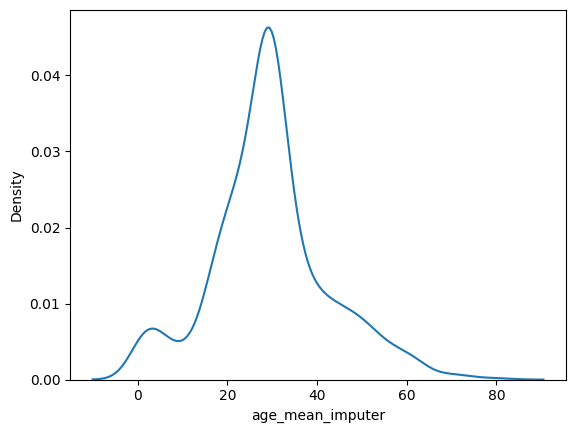

In [25]:
sns.kdeplot(data=X_train, x="age_mean_imputer")

<Axes: xlabel='age_median_imputer', ylabel='Density'>

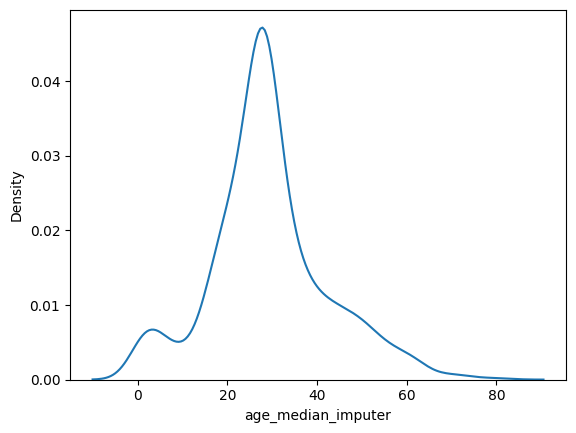

In [26]:
sns.kdeplot(data=X_train, x="age_median_imputer")

In [ ]:
# simple imputer class from sklearn
from sklearn.impute import SimpleImputer
import numpy as np
mean_imputer = SimpleImputer(strategy='mean', missing_values=np.nan)
mean_imputer.fit(X_train[['Age']])
X_train["Age"] = mean_imputer.transform(X_train[['Age']]).ravel() # ravel() is used to convert the 2D array returned by transform() into a 1D array
X_train.isnull().sum()

Pclass                0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Fare                  0
Embarked              2
age_mean_imputer      0
age_median_imputer    0
dtype: int64

In [28]:
X_train.drop(columns=['age_mean_imputer', 'age_median_imputer'], inplace=True)

In [ ]:
X_test["Age"] = mean_imputer.transform(X_test[['Age']]).ravel()
X_test.isnull().sum()

Pclass                0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Fare                  0
Embarked              0
age_mean_imputer      0
age_median_imputer    0
dtype: int64

In [30]:
X_test.drop(columns=['age_mean_imputer', 'age_median_imputer'], inplace=True)

In [31]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,no,third,male,22.0,1,0,7.2500,S
1,yes,first,female,38.0,1,0,71.2833,C
2,yes,third,female,26.0,0,0,7.9250,S
3,yes,first,female,35.0,1,0,53.1000,S
4,no,third,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,S
887,yes,first,female,19.0,0,0,30.0000,S
888,no,third,female,NaN,1,2,23.4500,S
889,yes,first,male,26.0,0,0,30.0000,C


# 3.9 Categorical Value Imputation with Mode Value

<Axes: xlabel='Pclass', ylabel='count'>

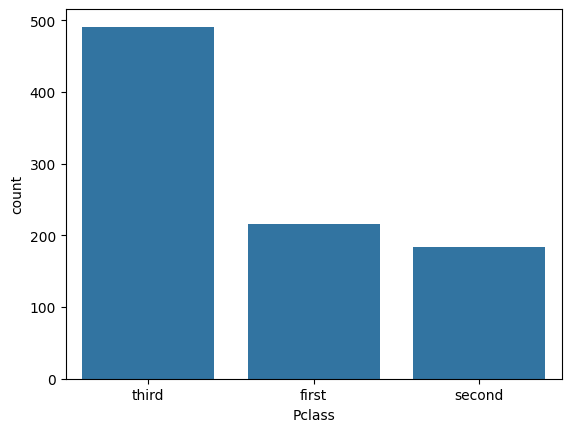

In [33]:
sns.countplot(data=df, x='Pclass')

In [34]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [35]:
# embarked has 2 missing values, we can fill those with the most frequent value which is S from countplot above
embarked_imputer = SimpleImputer(strategy='most_frequent', missing_values=np.nan)
embarked_imputer.fit(X_train[['Embarked']])
X_train['Embarked'] = embarked_imputer.transform(X_train[['Embarked']]).ravel() # ravel() is used to convert the 2D array returned by transform() into a 1D array

embarked_imputer.fit(X_test[['Embarked']])
X_test['Embarked'] = embarked_imputer.transform(X_test[['Embarked']]).ravel()

In [37]:
X_train.isnull().sum()
X_test.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

# 3.10 Categorical Value Imputation with Missing string and Indicator

jokhn kon dhoroner value diye impute kora lagbe sure na, suppose 2 ta mean or 2 ta median ashlo, then eta use kora hoy

In [42]:
print(df.isnull().sum())

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


<Axes: xlabel='Age', ylabel='count'>

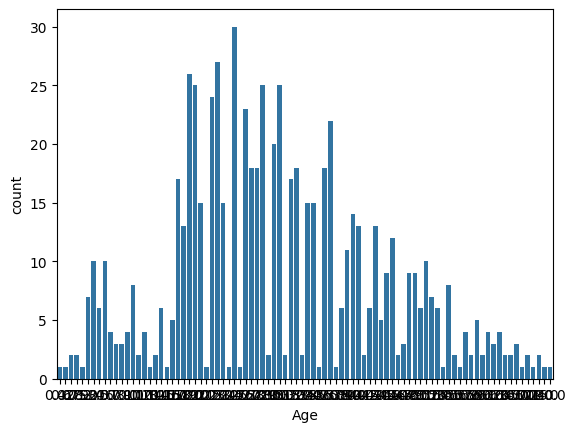

In [41]:
sns.countplot(data=df, x='Age')

In [45]:
age_imputer = SimpleImputer(strategy='constant', missing_values=np.nan, fill_value=-1, add_indicator=True)
age_imputer.fit(X_train[['Age']])
X_train[['Age','age_missing_indicator']] = age_imputer.transform(X_train[['Age']])

age_imputer.fit(X_test[['Age']])
X_test[['Age', 'age_missing_indicator']] = age_imputer.transform(X_test[['Age']])

ValueError: Columns must be same length as key

In [46]:
df2 = pd.read_csv('titanic_data_updated.csv')

In [47]:
df2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [48]:
df2.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64